# objective

predict churn

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('customers_inactivity.csv')

In [117]:
df.head()

,ssn,cc_num,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,acct_num,profile,last_trans_date,days_inactive,flag_churn
0,452-15-0123,2710115300059790,Julie,Davis,F,87318 Jones Spring,Middletown,MD,21769,39.4416,-77.5502,11236,Chartered public finance accountant,1998-10-27,637867261095,adults_2550_female_urban.json,2026-01-01,0.0,0
1,845-72-1034,4754337808105270,Mary,Jackson,F,721 Drew Key,Bloomfield Hills,MI,48301,42.5445,-83.2792,45496,Clinical psychologist,1952-03-24,583930581416,adults_50up_female_urban.json,2026-01-01,0.0,0
2,313-59-0649,6502424270965751,Kevin,Mcdonald,M,9278 Phillips Crossing,Murfreesboro,NC,27855,36.4319,-77.1027,6456,Electronics engineer,1991-10-10,478529471101,adults_2550_male_urban.json,2026-01-01,0.0,0
3,543-14-7950,6535129425711635,Anthony,Mitchell,M,81547 Brenda Walks,Trabuco Canyon,CA,92679,33.6415,-117.5894,33105,"Buyer, industrial",1999-07-18,471109951159,adults_2550_male_urban.json,2026-01-01,0.0,0
4,104-51-3189,3583538629340587,Brittany,Knox,F,2209 Sara Ville Apt. 520,Rowland Heights,CA,91748,33.9818,-117.8969,45406,"Biochemist, clinical",1965-05-14,97230672739,adults_50up_female_urban.json,2025-12-31,1.0,0


In [118]:
df.shape

(6000, 19)

In [119]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ssn              6000 non-null   str    
 1   cc_num           6000 non-null   int64  
 2   first            6000 non-null   str    
 3   last             6000 non-null   str    
 4   gender           6000 non-null   str    
 5   street           6000 non-null   str    
 6   city             6000 non-null   str    
 7   state            6000 non-null   str    
 8   zip              6000 non-null   int64  
 9   lat              6000 non-null   float64
 10  long             6000 non-null   float64
 11  city_pop         6000 non-null   int64  
 12  job              6000 non-null   str    
 13  dob              6000 non-null   str    
 14  acct_num         6000 non-null   int64  
 15  profile          6000 non-null   str    
 16  last_trans_date  5207 non-null   str    
 17  days_inactive    6000 non

In [120]:
df.nunique()

ssn                6000
cc_num             6000
first               611
last                954
gender                2
street             6000
city               2696
state                51
zip                4642
lat                4576
long               4607
city_pop           3118
job                 639
dob                5291
acct_num           6000
profile              12
last_trans_date       5
days_inactive         6
flag_churn            2
dtype: int64

In [121]:
df.isnull().sum()

ssn                  0
cc_num               0
first                0
last                 0
gender               0
street               0
city                 0
state                0
zip                  0
lat                  0
long                 0
city_pop             0
job                  0
dob                  0
acct_num             0
profile              0
last_trans_date    793
days_inactive        0
flag_churn           0
dtype: int64

In [ ]:
# all churns are from clients w no transactions from before the start date
df[(df['flag_churn'] == 1) & (df['days_inactive'] != 365)]

,ssn,cc_num,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,acct_num,profile,last_trans_date,days_inactive,flag_churn


In [ ]:
df_trans = pd.read_csv('trx_nofraud.csv')

In [130]:
df_trans.info()

<class 'pandas.DataFrame'>
RangeIndex: 4645844 entries, 0 to 4645843
Data columns (total 27 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Unnamed: 0  int64  
 1   ssn         str    
 2   cc_num      int64  
 3   first       str    
 4   last        str    
 5   gender      str    
 6   street      str    
 7   city        str    
 8   state       str    
 9   zip         int64  
 10  lat         float64
 11  long        float64
 12  city_pop    int64  
 13  job         str    
 14  dob         str    
 15  acct_num    int64  
 16  profile     str    
 17  trans_num   str    
 18  trans_date  str    
 19  trans_time  str    
 20  unix_time   float64
 21  category    str    
 22  amt         float64
 23  is_fraud    float64
 24  merchant    str    
 25  merch_lat   float64
 26  merch_long  float64
dtypes: float64(7), int64(5), str(15)
memory usage: 957.0 MB


In [127]:
cc = 4875998239861890
churned_customer = df_trans[df_trans['cc_num']== cc]
churned_customer = churned_customer.sort_values('trans_date')

churned_customer

,Unnamed: 0,ssn,cc_num,first,last,gender,street,city,state,zip,...,trans_num,trans_date,trans_time,unix_time,category,amt,is_fraud,merchant,merch_lat,merch_long
53,71,225-07-7554,4875998239861890,Amber,Smith,F,365 Martin Lake Suite 357,Mc Cool,MS,39108,...,f9c2edd53de67f8d58aa79b4dbdfdbea,2025-01-03,02:31:53,1.735882e+09,gas_transport,83.27,0.0,"fraud_Olson, Becker and Koch",32.315404,-90.030282
48,66,225-07-7554,4875998239861890,Amber,Smith,F,365 Martin Lake Suite 357,Mc Cool,MS,39108,...,4e8e8614af57fc23fef5c25921cf8d9b,2025-01-03,01:26:13,1.735878e+09,gas_transport,80.18,0.0,"fraud_Christiansen, Goyette and Schamberger",34.033205,-88.798954
124,142,225-07-7554,4875998239861890,Amber,Smith,F,365 Martin Lake Suite 357,Mc Cool,MS,39108,...,81ff2a71e702d014164671173928aaa3,2025-01-03,11:34:01,1.735915e+09,gas_transport,25.46,0.0,"fraud_Jenkins, Hauck and Friesen",33.068894,-89.794260
52,70,225-07-7554,4875998239861890,Amber,Smith,F,365 Martin Lake Suite 357,Mc Cool,MS,39108,...,90ee020181bb6b5ba704940db68c7a3f,2025-01-03,02:54:26,1.735884e+09,gas_transport,49.87,0.0,fraud_Luettgen PLC,32.502181,-89.503005
1,19,225-07-7554,4875998239861890,Amber,Smith,F,365 Martin Lake Suite 357,Mc Cool,MS,39108,...,8250aab44a8ff8b1c7e43fe6771812d8,2025-01-04,06:46:41,1.735984e+09,gas_transport,77.19,0.0,fraud_Kutch LLC,32.762747,-90.024044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490,508,225-07-7554,4875998239861890,Amber,Smith,F,365 Martin Lake Suite 357,Mc Cool,MS,39108,...,e1d36e350838ea1278a24dab9c05bb15,2025-12-29,20:57:00,1.767053e+09,travel,4.01,0.0,fraud_Satterfield-Lowe,32.720109,-89.143577
185,203,225-07-7554,4875998239861890,Amber,Smith,F,365 Martin Lake Suite 357,Mc Cool,MS,39108,...,39b1801c260653eae9bda05c40c2a341,2025-12-29,20:22:39,1.767051e+09,travel,114.44,0.0,fraud_Kovacek Ltd,32.647593,-89.514709
378,396,225-07-7554,4875998239861890,Amber,Smith,F,365 Martin Lake Suite 357,Mc Cool,MS,39108,...,ea68a8e3e54de1491aba08197d361eb2,2025-12-30,15:38:44,1.767120e+09,travel,84.15,0.0,fraud_Mosciski Group,34.012398,-89.200386
642,660,225-07-7554,4875998239861890,Amber,Smith,F,365 Martin Lake Suite 357,Mc Cool,MS,39108,...,afb46f410b4e2b6d7a7b499a0ba47fb2,2025-12-30,20:09:53,1.767136e+09,travel,38.96,0.0,fraud_Kozey-McDermott,33.147228,-89.809487


<Axes: xlabel='trans_date', ylabel='amt'>

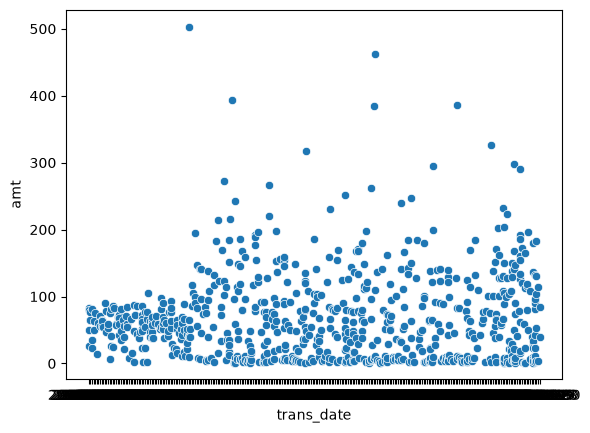

In [128]:
sns.scatterplot(churned_customer, x='trans_date', y = 'amt')